# Novo Ensino Suplementar (NES)
## Inteligência Artificial e Banco de Dados
### Aula 5 - Regressão Linear e Polinomial
#### Dr. Leonardo Medeiros


# Regressão Linear

In [2]:
#Manual
import pandas as pd
import numpy as np
#the csv file is located in a previous subdirectory called tables
train_dataset = pd.read_csv('/home/nes_pedro/FUND-IA/DATABASES/dadosprecocivic.csv', sep=";")
print(train_dataset['kilometragem-x'])
X = train_dataset['kilometragem-x']
Y = train_dataset['preco-y']
mediaX = np.mean(X)
mediaY = np.mean(Y)
stdX = np.std(train_dataset['kilometragem-x'], ddof=1)
stdY = np.std(train_dataset['preco-y'], ddof=1)
#ddof : int, optional
    #Means Delta Degrees of Freedom. The divisor used in calculations is
    #N - ddof, where N represents the number of elements. By default ddof is zero.
#Because this parameter we get the diference between Excel and Numpy result.
print("Media X %d", mediaX)
print("Media Y %d",mediaY)
print("Desvio Padrao X %d",stdX)
print("Desvio Padrao Y %d",stdY)
deviationX = X - mediaX
deviationY = Y - mediaY
sumCovariance = np.sum(deviationX*deviationY)
print("Soma da Covariancia %d", sumCovariance)
#Number of instances
N = train_dataset.shape[0]
print(N)
pearsonCorrelation = sumCovariance/((N-1)*stdX*stdY)
print("Correlacao %.4f", pearsonCorrelation)

beta = pearsonCorrelation * (stdY/stdX)
alpha = mediaY-(beta*mediaX)
print("Beta %d", beta)
print("Alpha %d", alpha)


0       9300
1      10565
2      15000
3      15000
4      17764
5      57000
6      65940
7      73676
8      77006
9      93739
10    146088
11    153260
Name: kilometragem-x, dtype: int64
Media X %d 61194.833333333336
Media Y %d 4998.75
Desvio Padrao X %d 50988.830753470516
Desvio Padrao Y %d 4078.5158424692586
Soma da Covariancia %d -1466216047.5
12
Correlacao %.4f -0.6409557923377475
Beta %d -0.05126903901780507
Alpha %d 8136.150297854745


(Beta) Inclinacao %d -0.051269039017805086
(Alpha) Intercept %d 8136.150297854746
Coeficiente  Correlacao %d -0.6409557923377475
P Value %d 0.024707725485408644
Erro do Desvio Padrao %d 0.019415541320966446


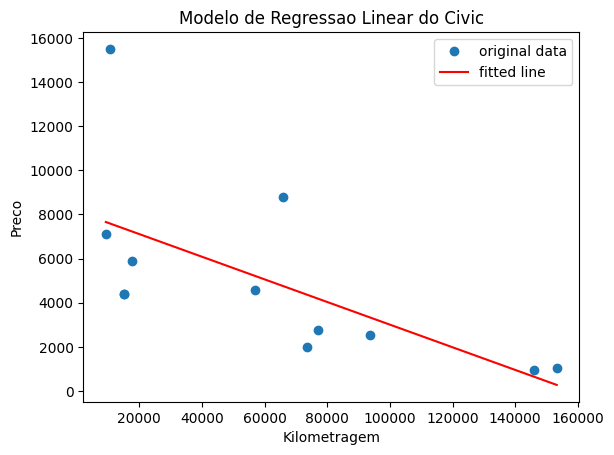

In [1]:
#Usando Stats
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
#the csv file is located in a previous subdirectory called tables
train_dataset = pd.read_csv('dadosprecocivic.csv', sep=";")
X = train_dataset['kilometragem-x']
Y = train_dataset['preco-y']
#slope = inclinacao
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
print("(Beta) Inclinacao %d", slope)
print("(Alpha) Intercept %d", intercept)
print("Coeficiente  Correlacao %d", r_value)
#two-sided p-value for a hypothesis test whose null hypothesis is that the slope is zero
print("P Value %d", p_value)
#Standard error of the estimated gradient.
print("Erro do Desvio Padrao %d", std_err)
plt.title('Modelo de Regressao Linear do Civic')
plt.xlabel('Kilometragem')
plt.ylabel('Preco')
plt.plot(X, Y, 'o', label = 'original data')
plt.plot(X, intercept + slope*X , 'r', label='fitted line')
plt.legend()
plt.show()


## Erro Quadrático

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
#the csv file is located in a previous subdirectory called tables
train_dataset = pd.read_csv('dadosprecocivic.csv', sep=";")
X = train_dataset['kilometragem-x']
Y = train_dataset['preco-y']
#slope = inclinacao
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
erroquadratico = r_value ** 2
print("slope", slope)
print("intercept", intercept)
print("r_value", r_value)
print("p_value", p_value)
print("std_err", std_err)
print("Erro Quadratico%d", erroquadratico)


slope -0.051269039017805086
intercept 8136.150297854746
r_value -0.6409557923377475
p_value 0.024707725485408644
std_err 0.019415541320966446
Erro Quadratico%d 0.41082432773130967


# Regressão Polinomial

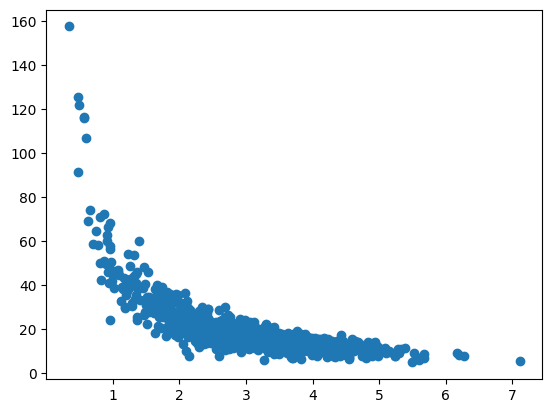

In [10]:
#Dispersão dos Dados
import matplotlib.pyplot as plt
from pylab import *
import numpy as np
np.random.seed(2)
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds
plt.scatter(pageSpeeds, purchaseAmount)
plt.show()

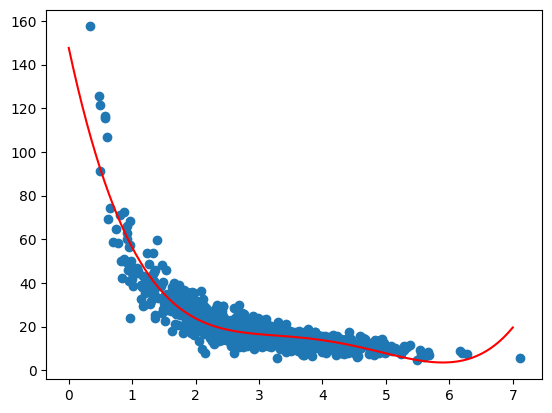

In [11]:
#Ajuste da Curva
import matplotlib.pyplot as plt
from pylab import *
import numpy as np
np.random.seed(2)
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds
x = np.array(pageSpeeds)
y = np.array(purchaseAmount)
p4 = np.poly1d(np.polyfit(x, y, 4))
xp = np.linspace(0, 7, 100)
plt.scatter(x, y)
plt.plot(xp, p4(xp), c='r')
plt.show()


In [13]:
#Erro Quadrático
import matplotlib.pyplot as plt
from pylab import *
import numpy as np
from sklearn.metrics import r2_score
np.random.seed(2)
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds
x = np.array(pageSpeeds)
y = np.array(purchaseAmount)
p4 = np.poly1d(np.polyfit(x, y, 4))
r2 = r2_score(y, p4(x))
print(r2)

0.8293766396303073


# Regressão Multivariada


In [24]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_excel('cars.xls')

# Seleção de variáveis
X = df[['Mileage', 'Cylinder', 'Doors']]
y = df['Price']

# Normalização
scale = StandardScaler()
X = pd.DataFrame(scale.fit_transform(X), columns=X.columns)

# Adiciona constante (intercepto)
X = sm.add_constant(X)

print(X)

# Modelo
est = sm.OLS(y, X).fit()
print(est.summary())

     const   Mileage  Cylinder     Doors
0      1.0 -1.417485   0.52741  0.556279
1      1.0 -1.305902   0.52741  0.556279
2      1.0 -0.810128   0.52741  0.556279
3      1.0 -0.426058   0.52741  0.556279
4      1.0  0.000008   0.52741  0.556279
..     ...       ...       ...       ...
799    1.0 -0.439853   0.52741  0.556279
800    1.0 -0.089966   0.52741  0.556279
801    1.0  0.079605   0.52741  0.556279
802    1.0  0.750446   0.52741  0.556279
803    1.0  1.932565   0.52741  0.556279

[804 rows x 4 columns]
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     150.0
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           3.95e-77
Time:                        18:38:41   Log-Likelihood:                -8356.7
No. Observ

MSE Linear: 0.7083953929786899


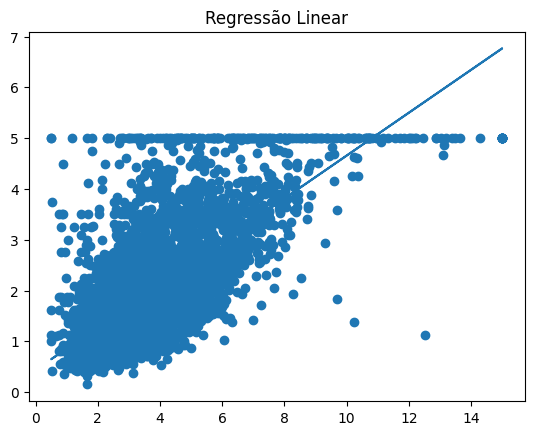

MSE Polinomial: 0.691438659065741
CV Linear: 0.7231529493564787
CV Polinomial: 0.7074069193845446


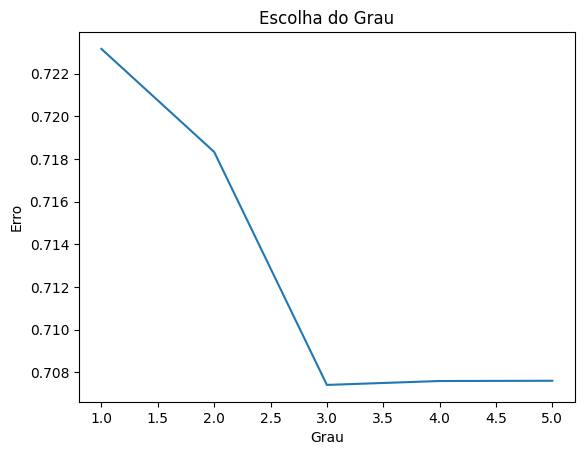

In [2]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# ==============================
# DATASET
# ==============================
data = fetch_california_housing()
X = data.data[:, 0].reshape(-1,1)  # renda média
y = data.target
# ==============================
# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ==============================
# REGRESSÃO LINEAR
# ==============================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

pred = lin_model.predict(X_test)
print("MSE Linear:", mean_squared_error(y_test, pred))

# ==============================
# GRÁFICO
# ==============================
plt.scatter(X_test, y_test)
plt.plot(X_test, pred)
plt.title("Regressão Linear")
plt.show()

# ==============================
# POLINOMIAL
# ==============================
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("lin", LinearRegression())
])

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

print("MSE Polinomial:", mean_squared_error(y_test, pred_poly))

# ==============================
# VALIDAÇÃO CRUZADA
# ==============================
scores = cross_val_score(lin_model, X, y, cv=5, scoring="neg_mean_squared_error")
print("CV Linear:", -scores.mean())

scores_poly = cross_val_score(poly_model, X, y, cv=5, scoring="neg_mean_squared_error")
print("CV Polinomial:", -scores_poly.mean())

# ==============================
# COMPARAÇÃO DE GRAUS
# ==============================
degrees = [1,2,3,4,5]
errors = []

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("lin", LinearRegression())
    ])
    score = -cross_val_score(model, X, y, cv=5,
                             scoring="neg_mean_squared_error").mean()
    errors.append(score)

plt.plot(degrees, errors)
plt.xlabel("Grau")
plt.ylabel("Erro")
plt.title("Escolha do Grau")
plt.show()

## Regressão KNN

In [15]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

# Carregar dados
data = fetch_california_housing()
X = data.data
y = data.target

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Modelo
K = 9
knn = KNeighborsRegressor(n_neighbors=K)

# Treinar
knn.fit(X_train, y_train)

# Testar
print("Valor real:", y_test[0])
print("Previsão:", knn.predict([X_test[0]]))

Valor real: 1.369
Previsão: [1.87633333]


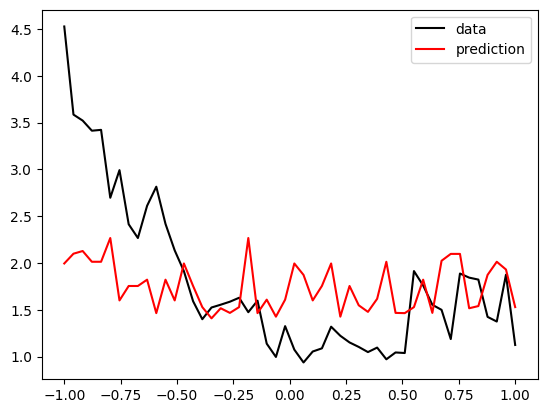

In [17]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
data = fetch_california_housing()
K = 9
knn = KNeighborsRegressor(n_neighbors=K)
x, y = data.data[:50], data.target[:50]
y_ = knn.fit(x, y).predict(x)
plt.plot(np.linspace(-1, 1, 50), y, label='data', color='black')
plt.plot(np.linspace(-1, 1, 50), y_, label='prediction', color='red')
plt.legend()

plt.show()